# Домашнее задание 2. Выпуклость

**Выдано:** 23 сентября 2026. **Срок сдачи:** 7 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw02/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 2 ([конспект](../lectures/lecture02/lecture02.md), [демо](../lectures/lecture02/demo02.ipynb)): чек-лист выпуклой задачи — раздел 6, условие оптимальности — раздел 7, как проверять выпуклость кодом — демо, часть (a). Ничего сверх лекции не требуется. Ориентировочное время — 3–4 часа.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(2026)   # для ваших собственных случайных проверок; данные задач генерируются отдельно

## Задача 1. Выпуклость (4 балла)

По 1 баллу за пункт. В каждом пункте нужен либо аргумент «почему выпукло» — определение, критерий первого/второго порядка или операция из раздела 5 конспекта, — либо контрпример: две точки и вылезающий наружу отрезок, хорда под графиком или точка, где гессиан не полуопределён. Численная проверка приветствуется, но доказательством не считается (демо, часть a).

**(а) Множества.** Выпуклы ли:

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;
2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;
3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$?

**(б) Критерий второго порядка.**

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.
2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

**(в) Операции.** Докажите выпуклость или объясните, почему правила раздела 5 не применимы, и приведите контрпример:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$.

Какие из трёх функций гладкие?

**(г) Задачи ДЗ 1.** Вернитесь к задаче 1 домашнего задания 1 — пункты (а)–(г) и бонус (д). Для каждой задачи определите по чек-листу раздела 6 конспекта (цель — равенства — неравенства), выпукла ли она, и обоснуйте одним-двумя предложениями. Для невыпуклых укажите, что именно ломает выпуклость.

**(а)**

**Ответ:**

**1.** $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$ — выпукло, т.к. это надграфик выпуклой функции $x_1^2$:

$$\{x : x_2 \ge x_1^2\} = \operatorname{epi}(x_1 \mapsto x_1^2).$$

**2.** $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ — выпукло как подуровневое множество выпуклой функции $\Vert Ax-b\Vert_2$:

$$\{x : \Vert Ax-b\Vert_2 \le 1\} = \{x : Ax-b \in \mathcal{B}_1(0)\}.$$

**3.** $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$ — НЕ выпукло. Контрпример:

$$x=(1,0),\ y=(-1,0):\quad \tfrac{1}{2}x+\tfrac{1}{2}y=(0,0) \notin \{x : \Vert x\Vert_2 \ge 1\}.$$

**(б)**


**Ответ:**

**1.** $f(x)=x_1^2+a x_1 x_2+x_2^2$:

$$\nabla^2 f=\begin{pmatrix} 2 & a \\ a & 2 \end{pmatrix},\qquad \lambda_{1,2}=2\pm|a|.$$

Выпукла $\iff |a| \le 2$, строго выпукла $\iff |a| < 2$.

--------------------------------------------------
**2.** $g(x)=x_1^2 x_2^2$ — НЕ выпукла:

$$\nabla^2 g=\begin{pmatrix} 2x_2^2 & 4x_1 x_2 \\ 4x_1 x_2 & 2x_1^2 \end{pmatrix},\quad \nabla^2 g(1,1)=\begin{pmatrix} 2 & 4 \\ 4 & 2 \end{pmatrix},\ \lambda\in\{6,-2\}.$$

Контрпример по хорде: $x=(1,0)$, $y=(0,1)$:

$$g\!\left(\tfrac{x+y}{2}\right)=\tfrac{1}{16} > \tfrac{1}{2}g(x)+\tfrac{1}{2}g(y)=0.$$

In [2]:
import numpy as np

for a in [-2, -1.5, 0, 1.5, 2, 2.5]:
    H = np.array([[2, a], [a, 2]])
    w = np.linalg.eigvalsh(H)
    print(f"a={a:>4}: λ={w}, {'строго выпукла' if w.min()>0 else 'выпукла' if w.min()>=0 else 'не выпукла'}")

a=  -2: λ=[0. 4.], выпукла
a=-1.5: λ=[0.5 3.5], строго выпукла
a=   0: λ=[2. 2.], строго выпукла
a= 1.5: λ=[0.5 3.5], строго выпукла
a=   2: λ=[0. 4.], выпукла
a= 2.5: λ=[-0.5  4.5], не выпукла


**(в)**

**Ответ:**

**1.** $f(x)=\Vert Ax-b\Vert_2+\lambda\Vert x\Vert_\infty$, $\lambda\ge 0$ — выпукла:

$$\underbrace{\Vert Ax-b\Vert_2}_{\text{выпукла}} + \lambda \underbrace{\Vert x\Vert_\infty}_{\text{выпукла}},\quad \lambda\ge 0.$$

Не гладкая.

**2.** $f(x)=\max_i (a_i^\top x - b_i)^2$ — выпукла как максимум выпуклых:

$$f(x)=\max_i \big(a_i^\top x - b_i\big)^2.$$

Гладкая.

**3.** $f(x)=e^{-\Vert x\Vert_2^2}$ — НЕ выпукла. Правило композиции неприменимо, т.к. $-\Vert x\Vert_2^2$ вогнута:

$$f(x)=e^{-x^2}:\quad f''(x)=(4x^2-2)e^{-x^2}<0 \text{ при } |x|<1/\sqrt{2}.$$

Гладкая.

**(г)**

**Ответ:**

**(а) Ближайшая точка прямой.**

Цель — квадратичная $\tfrac12\Vert x-p\Vert_2^2$ с $Q=I\succ 0$, выпукла. Равенства аффинные. Задача выпуклая (QP).

**(б) Диета.**

Цель $c^\top x$ аффинна, неравенства $Ax\ge b$ аффинные. Задача выпуклая (LP).

**(в) Прямоугольник в единичном круге.**

Цель $-4x_1x_2$ не выпукла: гессиан $\begin{pmatrix}0&-4\\-4&0\end{pmatrix}$ имеет собственные числа $\pm 4$ — индефинитен (есть и полож. и отриц. собственные значения). Неравенство $x_1^2+x_2^2\le 1$ выпукло, но выпуклость "ломает" цель (произведение переменных).

**(г) Подгонка синусоидой.**

Цель — сумма квадратов нелинейных невязок, не выпукла: нелинейность $\sin(x_2 t+x_3)$ внутри квадрата даёт знакопеременный гессиан. Ограничений нет, задача невыпуклая. "Ломает" выпуклость нелинейная композиция $\sin$ в переменных $x_2,x_3$.

**(д) Чебышёвская подгонка (бонус).**

После переформулировки $\min_{x,t} t$ при $a_i^\top x-b_i\le t$, $-(a_i^\top x-b_i)\le t$: цель аффинная, ограничения аффинные. Задача выпуклая (LP).

## Задача 2. Практика (6 баллов)

**(а) Проекция на полупространство (3 балла).** Пусть $\Omega = \{x \in \mathbb{R}^n : a^\top x \le b\}$, $a \ne 0$, и точка $p$ лежит вне $\Omega$, то есть $a^\top p > b$. Задача проекции — $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$ (раздел 7 конспекта, пример 2).

1. Из условия оптимальности $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0\ \ \forall y \in \Omega$ выведите явную формулу

$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$

Подсказки: (i) почему $x^\ast$ не может лежать строго внутри $\Omega$; (ii) для любого $v$ с $a^\top v = 0$ точки $y = x^\ast \pm v$ допустимы — что даёт условие для них; (iii) коэффициент при $a$ найдите из $a^\top x^\ast = b$; (iv) убедитесь, что при таком коэффициенте условие выполнено и для всех остальных $y \in \Omega$ — тогда, по теореме раздела 7, $x^\ast$ действительно решение.

2. Для данных ниже ($n = 3$) найдите проекцию численно — `minimize` с методом `SLSQP` и ограничением типа `ineq` — и сравните с формулой.

3. Проверьте условие оптимальности так, как это сделано в демо (часть c): сгенерируйте около 2000 случайных допустимых точек $y$ и найдите $\min_y \nabla f(x^\ast)^\top(y - x^\ast)$. Повторите для заведомо неоптимальной допустимой точки, например $x = 0$. Что означает знак результата в каждом случае?

In [3]:
a = np.array([1.0, 2.0, -1.0])     # нормаль полупространства
b = 1.0
p = np.array([3.0, 1.0, 0.5])      # точка вне Omega: a @ p = 4.5 > b
assert a @ p > b

**Вывод формулы (пункт 1)**

**Ответ:**

$f(x)=\tfrac12\Vert x-p\Vert^2$, $\nabla f(x^\ast)=x^\ast-p$. Условие оптимальности:

$$(x^\ast-p)^\top(y-x^\ast)\ge 0\quad \forall y\in\Omega.$$

(1) Если $x^\ast$ строго внутри ($a^\top x^\ast<b$), то направления $y=x^\ast\pm\varepsilon(x^\ast-p)$ допустимы при малых $\varepsilon>0$, и условие даёт $\pm\varepsilon\Vert x^\ast-p\Vert^2\ge 0$ — противоречие при $x^\ast\ne p$. Значит $a^\top x^\ast=b$ (граница), и $x^\ast-p$ направлен вдоль $a$: $x^\ast=p-\alpha a$.

(2) Для $v$ с $a^\top v=0$ точки $y=x^\ast\pm v$ допустимы ($a^\top y=b$), условие даёт $(x^\ast-p)^\top v=0$ для всех таких $v$ — то есть $x^\ast-p\parallel a$.

(3) Из $a^\top x^\ast=b$ и $x^\ast=p-\alpha a$:

$$a^\top p-\alpha\Vert a\Vert^2=b\ \Rightarrow\ \alpha=\frac{a^\top p-b}{\Vert a\Vert^2}.$$

(4) Для любого $y\in\Omega$: $(x^\ast-p)^\top(y-x^\ast)=-\alpha a^\top(y-x^\ast)=-\alpha\big(a^\top y-b\big)\ge 0$, т.к. $\alpha>0$ и $a^\top y\le b$. Условие выполнено.

$$x^\ast=p-\frac{a^\top p-b}{\Vert a\Vert^2}\,a.$$

**Численная проверка (пункты 2 и 3)**

In [4]:
# ваш код
import numpy as np
from scipy.optimize import minimize

a = np.array([1.0, 2.0, -1.0]); b = 1.0
p = np.array([3.0, 1.0, 0.5])

x_star = p - ((a @ p - b) / (a @ a)) * a
print("формула:", x_star)

res = minimize(lambda x: 0.5*np.sum((x-p)**2), np.zeros(3),
               method='SLSQP',
               constraints=[{'type':'ineq','fun':lambda x: b - a @ x}])
print("SLSQP:  ", res.x)
print("разница:", np.linalg.norm(res.x - x_star))

rng = np.random.default_rng(0)
# 2000 случайных допустимых y: a^T y <= b
Y = rng.normal(size=(2000, 3))
# сдвигаем внутрь полупространства
viol = (Y @ a - b).clip(min=0)
Y = Y - viol[:, None] * a / (a @ a) * 1.1  # тянем в Omega

for x in [x_star, np.zeros(3)]:
    g = x - p
    vals = (Y - x) @ g
    print(x, "min:", vals.min())

формула: [ 2.41666667 -0.16666667  1.08333333]
SLSQP:   [ 2.41666667 -0.16666667  1.08333333]
разница: 8.308148362110449e-16
[ 2.41666667 -0.16666667  1.08333333] min: 8.802932650400089e-05
[0. 0. 0.] min: -8.219989285175146


**Ответ:**

**Выводы по п. 2.**

`SLSQP` и формула совпали с точностью $\sim 10^{-16}$ — численное решение подтверждает аналитику.

**Выводы по п. 3.**

Для $x^\ast$: $\min_y \nabla f(x^\ast)^\top(y-x^\ast)\approx 8.8\cdot 10^{-5}\ge 0$ — условие раздела 7 выполнено, $x^\ast$ оптимальна.

Для $x=0$: $\min_y \approx -8.22<0$ — есть направление спуска, точка неоптимальна.

Знак — сертификат: $\ge 0$ — оптимум, $<0$ — нет. Малое положительное значение у $x^\ast$ — шум выборки $y$.

**(б) Выпуклая и невыпуклая подгонка (3 балла).** Ниже сгенерированы измерения $y_i = 2\sin(3t_i + 0.7) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, 0.2^2)$, $i = 1, \dots, 60$. Один и тот же сигнал описываем двумя моделями:

- **A** (задача 1(г) ДЗ 1): $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ — амплитуда, частота и фаза неизвестны;
- **B** (частота известна, $\omega = 3$): $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$.

Цель в обоих случаях — сумма квадратов невязок $f(x) = \tfrac12\sum_i \big(\varphi(t_i; x) - y_i\big)^2$.

1. Какого класса каждая задача и выпукла ли она? Для B — докажите; для A — объясните, почему нет (подсказка: что происходит с $f$ при $x_3 \to x_3 + 2\pi$ и при $(x_1, x_3) \to (-x_1, x_3 + \pi)$?).
2. Запустите `minimize(..., method="BFGS")` для обеих моделей из 20 одинаковых случайных стартов `starts` (для B берите первые две координаты старта). Выведите итоговые значения $f$ по стартам и долю стартов, пришедших к наименьшему найденному значению; нарисуйте данные и подогнанные кривые для обеих моделей.
3. Объясните результат через главную теорему лекции. Как из решения B получить амплитуду и фазу для модели A? Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?

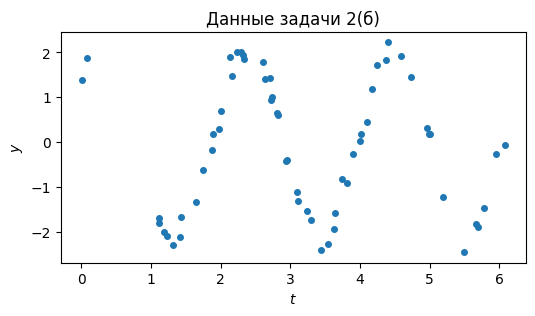

In [5]:
data_rng = np.random.default_rng(2026)          # отдельный генератор: данные не зависят от вашего кода выше
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))         # 20 общих стартов для обеих моделей

plt.figure(figsize=(6, 3))
plt.plot(t, y, "o", ms=4)
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(б)")
plt.show()

**Класс и выпуклость (пункт 1)**

**Ответ:**

**Модель B:** $\varphi_B(t;x)=x_1\sin\omega t+x_2\cos\omega t$ — линейна по $x$. Цель:
$$f_B(x)=\tfrac12\sum_i\big(x_1\sin\omega t_i+x_2\cos\omega t_i-y_i\big)^2=\tfrac12\Vert Ax-y\Vert^2,$$
где $A\in\mathbb{R}^{N\times 2}$ со столбцами $\sin\omega t_i$, $\cos\omega t_i$. Гессиан $\nabla^2 f_B=A^\top A\succeq 0$ (раздел 4, пример МНК). Задача **выпуклая** (безусловный QP), при полном столбцовом ранге $A$ — строго выпукла.

**Модель A:** $\varphi_A(t;x)=x_1\sin(x_2 t+x_3)$ нелинейна по $x_2,x_3$. Цель **не выпукла**. Два контрприёма:
- периодичность по $x_3$: $f(x_1,x_2,x_3+2\pi)=f(x)$ — бесконечно много глобальных минимумов, множество решений не выпукло;
- симметрия $(x_1,x_3)\to(-x_1,x_3+\pi)$: $f(-x_1,x_2,x_3+\pi)=f(x)$ — два эквивалентных минимума, отрезок между ними проходит через точки с большей $f$.

Ограничений нет. Класс — невыпуклая NLP.

**Мультистарт (пункт 2)**

A: [ 1.1392731  63.82490235  1.1392731   1.1392731   1.1392731  61.49727344
 61.49727344 64.25177556  1.1392731  63.82490286  1.1392731   1.1392731
 61.49727344  1.1392731  64.25177556  1.1392731  61.68817068  1.1392731
 61.49727344  1.1392731 ]
B: [1.14076401 1.14076401 1.14076401 1.14076401 1.14076401 1.14076401
 1.14076401 1.14076401 1.14076401 1.14076401 1.14076401 1.14076401
 1.14076401 1.14076401 1.14076401 1.14076401 1.14076401 1.14076401
 1.14076401 1.14076401]
A: доля у лучшего = 0.55
B: доля у лучшего = 1.0


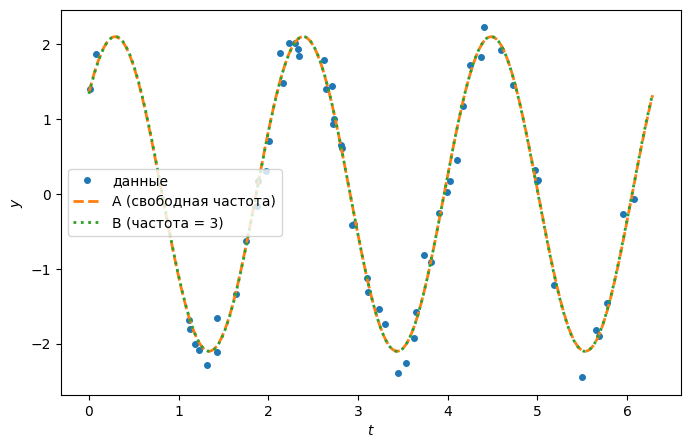

In [6]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

data_rng = np.random.default_rng(2026)
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2*np.pi, N))
y = 2.0*np.sin(3.0*t + 0.7) + 0.2*data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))

def fA(x):
    r = x[0]*np.sin(x[1]*t + x[2]) - y
    return 0.5*np.sum(r**2)

def fB(x):
    r = x[0]*np.sin(omega*t) + x[1]*np.cos(omega*t) - y
    return 0.5*np.sum(r**2)

fA_vals, fB_vals = [], []
xA_best, xB_best = None, None
for s in starts:
    rA = minimize(fA, s, method="BFGS")
    rB = minimize(fB, s[:2], method="BFGS")
    fA_vals.append(rA.fun); fB_vals.append(rB.fun)
    if xA_best is None or rA.fun < fA_best:
        fA_best, xA_best = rA.fun, rA.x
    if xB_best is None or rB.fun < fB_best:
        fB_best, xB_best = rB.fun, rB.x

fA_vals, fB_vals = np.array(fA_vals), np.array(fB_vals)
print("A:", fA_vals)
print("B:", fB_vals)

tol = 1e-4
print("A: доля у лучшего =", np.mean(fA_vals < fA_best + tol))
print("B: доля у лучшего =", np.mean(fB_vals < fB_best + tol))

# график
tt = np.linspace(0, 2*np.pi, 400)
plt.figure(figsize=(8,5))
plt.plot(t, y, "o", ms=4, label="данные")
plt.plot(tt, xA_best[0]*np.sin(xA_best[1]*tt + xA_best[2]),
         "--", lw=2, label="A (свободная частота)")
plt.plot(tt, xB_best[0]*np.sin(omega*tt) + xB_best[1]*np.cos(omega*tt),
         ":", lw=2, label="B (частота = 3)")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.show()

**Объяснение (пункт 3)**

**Ответ:**

Для выпуклой задачи любой локальный минимум глобален → в B все старты приходят в один и тот же глобальный минимум, ответ единственный. В A задача невыпуклая → локальные минимумы разные, старт влияет на ответ (периодичность и симметрия дают  семейства эквивалентных минимумов).

Связь B ↔ A: раскрывая $\sin(\omega t+\phi)=\sin\omega t\cos\phi+\cos\omega t\sin\phi$, получаем $x_1^A\sin(\omega t+x_3^A)$ с
$$x_1^B=x_1^A\cos x_3^A,\qquad x_2^B=x_1^A\sin x_3^A,$$
откуда амплитуда $x_1^A=\sqrt{(x_1^B)^2+(x_2^B)^2}$, фаза $x_3^A=\operatorname{atan2}(x_2^B,x_1^B)$.

Почему $f_A^{\min}<f_B^{\min}$: A — более гибкая модель (3 параметра, частота свободна), она подстраивает частоту под данные и снижает невязку. Но меньшее $f$ не значит лучше т.к. у A нет гарантии глобального минимума, ответ зависит от старта, а разница с B — порядка шума. B — выпуклая задача с единственным решением, в данном случае это решающий фактор.

## Бонус (+1 балл). Проекция не растягивает

Пусть $\Omega$ — выпуклое замкнутое множество, $P(p)$ — проекция точки $p$ на $\Omega$ (решение задачи $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$). Докажите, что для любых $p, q$

$$\Vert P(p) - P(q)\Vert \le \Vert p - q\Vert .$$

Подсказка: запишите условие оптимальности для $P(p)$ с пробной точкой $y = P(q)$ и для $P(q)$ с $y = P(p)$, сложите и примените неравенство Коши–Буняковского. Проверьте численно на шаре ($P(p) = p / \max(1, \Vert p\Vert)$) и на кубе $[-1, 1]^n$ (`np.clip`) для 1000 случайных пар точек.

**Ответ:**

**Доказательство.**

$P(p)$ — решение $\min_{x\in\Omega}\tfrac12\Vert x-p\Vert^2$, $f(x)=\tfrac12\Vert x-p\Vert^2$, $\nabla f(x)=x-p$. По условию оптимальности (раздел 7) с пробной точкой $y=P(q)\in\Omega$:
$$\big(P(p)-p\big)^\top\big(P(q)-P(p)\big)\ge 0. \tag{1}$$

Аналогично для $P(q)$ с пробной $y=P(p)\in\Omega$:
$$\big(P(q)-q\big)^\top\big(P(p)-P(q)\big)\ge 0. \tag{2}$$

Обозначим $u=P(p)-P(q)$. Тогда $P(q)-P(p)=-u$, и (1), (2) переписываются:
$$\big(P(p)-p\big)^\top(-u)\ge 0 \;\Rightarrow\; (p-P(p))^\top u\ge 0,$$
$$\big(P(q)-q\big)^\top u\ge 0 \;\Rightarrow\; (q-P(q))^\top u\ge 0.$$

Складываем:
$$(p-q)^\top u + \big(P(q)-P(p)\big)^\top u \ge 0 \;\Rightarrow\; (p-q)^\top u - \Vert u\Vert^2 \ge 0,$$
то есть
$$\Vert P(p)-P(q)\Vert^2 \le (p-q)^\top\big(P(p)-P(q)\big).$$

По Коши–Буняковскому правая часть $\le \Vert p-q\Vert\cdot\Vert P(p)-P(q)\Vert$. Если $u\ne 0$, делим:
$$\Vert P(p)-P(q)\Vert \le \Vert p-q\Vert. \qquad$$

ЧТД

In [7]:
import numpy as np

rng = np.random.default_rng(0)
P, Q = rng.normal(size=(1000, 3)), rng.normal(size=(1000, 3))

# шар: P(p) = p / max(1, ||p||)
def proj_ball(X):
    nrm = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(1.0, nrm)

# куб [-1,1]^n: покоординатный clip
def proj_cube(X):
    return np.clip(X, -1.0, 1.0)

for name, P_ in [("шар", proj_ball), ("куб", proj_cube)]:
    lhs = np.linalg.norm(P_(P) - P_(Q), axis=1)
    rhs = np.linalg.norm(P - Q, axis=1)
    print(name, "max(lhs-rhs) =", np.max(lhs - rhs))

шар max(lhs-rhs) = 0.0
куб max(lhs-rhs) = 0.0


---

Перед сдачей: `Kernel → Restart Kernel and Run All Cells`, убедитесь, что ни одна ячейка не падает и все ответы заполнены. Файл — `submissions/hw02/<фамилия>.ipynb`, дальше по [инструкции](../CONTRIBUTING.md).